# Change-point по правдоподобию фильтра Калмана

Проверка одной гипотезы. Фильтр подгоняется по точкам `move`. На штатном ходе невязка остаётся небольшой, а логарифм правдоподобия держится в узкой полосе. Первая точка `anomaly`, которая не продолжает это движение, должна увести правдоподобие вниз. В такой точке ставится `change_point`, и фильтр открывает новую локальную систему координат: начало отсчёта переносится в эту точку, состояние обнуляется. Точки между соседними `change_point` образуют один отрезок.

Ожидание: эти отрезки близки к нарезке ряда на непрерывные куски `move` и `anomaly`, и в первую очередь не смешивают один класс с другим.

Срез данных, очистка и размеры выборок те же, что в `example.ipynb`: `data/2.csv`, индексы `[200000, 350000)`, только `move` и `anomaly`, последние 50 000 точек — тест. Шум фильтра и порог правдоподобия выбираются по `move` обучения. Карта и метрики гипотезы считаются по тесту.

Две модели — те же, что в `app/old/working/kalman_filter_cv.py` и `kalman_filter_rw.py`.

- Постоянная скорость. Состояние \((e, n, v_e, v_n)\), белый шум ускорения \(\sigma_a\), шум измерения \(\sigma_{\mathrm{meas}}\).
- Случайное блуждание. Состояние \((e, n)\), \(Q = \sigma_{rw}^2 \Delta t \, I\).

Правдоподобие шага — плотность прогноза измерения:

\[
\log p(z_k \mid z_{1:k-1}) = -\frac12 \bigl(2\log 2\pi + \log\det S_k + \nu_k^\top S_k^{-1}\nu_k\bigr).
\]

Порог — квантиль 0,5% этого логарифма на шагах `move` обучения. На ходу такой `change_point` приходится примерно на один шаг из двухсот. Всё, что для подогнанной модели ещё менее правдоподобно, открывает новую систему.

In [1]:
import sys
import types
import importlib.util
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.collections import LineCollection
from scipy.stats import chi2
from shapely.geometry import LineString
from sklearn.metrics import adjusted_rand_score, homogeneity_completeness_v_measure

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

START_IND = 200_000
END_IND = 350_000
TEST_SIZE = 50_000
# Пауза, после которой прогноз постоянной скорости уже не имеет смысла.
# Та же граница, что у фильтра Калмана в example.ipynb.
GAP_SECONDS = 180.0
# Квантиль логарифма правдоподобия на move. Ниже него — change_point.
TAIL_PERCENT = 0.5
EARTH_RADIUS_M = 6_371_000.0
CHI2_MEDIAN = float(chi2.median(2))
# Окно карты example.ipynb: [юг, запад, север, восток].
MAP_BBOX = [50.524974, 44.809115, 54.250411, 52.029355]


def find_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data" / "2.csv").exists() and (candidate / "app").exists():
            return candidate
    raise FileNotFoundError("Не найден корень проекта с data/2.csv")


path_root = find_root()
path = path_root / "data" / "2.csv"
print(f"Корень: {path_root}")
print(f"Файл: {path}")
print(f"Медиана χ²(2) = {CHI2_MEDIAN:.3f}")

Корень: C:\Users\svaga\PycharmProjects\statistical_researchs
Файл: C:\Users\svaga\PycharmProjects\statistical_researchs\data\2.csv
Медиана χ²(2) = 1.386


# Данные

Из `data/2.csv` берётся фрагмент `raw.iloc[START_IND:END_IND]`. Удаляются `sat` и `is_water`, пустые координаты и нулевые широта или долгота. `stand` и любые другие метки отбрасываются. Оставшиеся `move` и `anomaly` сортируются по времени. Последние `TEST_SIZE` точек — тест, всё предыдущее — обучение. Параметры фильтра считаются только по непрерывным кускам `move` внутри обучения.

In [2]:
raw_full = pd.read_csv(path)
raw = raw_full.iloc[START_IND:END_IND].reset_index(drop=True)

frame = raw.drop(columns=["sat", "is_water"]).copy()
frame["lat"] = pd.to_numeric(frame["lat"], errors="coerce")
frame["lon"] = pd.to_numeric(frame["lon"], errors="coerce")
keep = frame["lat"].notna() & frame["lon"].notna() & (frame["lat"] != 0.0) & (frame["lon"] != 0.0)
frame = frame.loc[keep].reset_index(drop=True)
status = frame["status"].astype(str)
n_stand = int((status == "stand").sum())
n_other = int((~status.isin(["move", "anomaly", "stand"])).sum())
frame = frame.loc[status.isin(["move", "anomaly"])].reset_index(drop=True)
order = np.argsort(pd.to_datetime(frame["time"]).to_numpy(), kind="mergesort")
frame = frame.iloc[order].reset_index(drop=True)

if len(frame) <= TEST_SIZE:
    raise RuntimeError(
        f"После очистки осталось {len(frame)} строк, этого мало для теста из {TEST_SIZE}."
    )

stamp = pd.to_datetime(frame["time"])
t_sec = stamp.to_numpy().astype("datetime64[ns]").astype(np.int64) / 1e9
lat = frame["lat"].to_numpy(dtype=float)
lon = frame["lon"].to_numpy(dtype=float)
anom = frame["status"].astype(str).to_numpy() == "anomaly"
if np.any(np.diff(t_sec) <= 0.0):
    raise RuntimeError("Время после сортировки не строго возрастает.")

train_end = len(frame) - TEST_SIZE


def nfmt(value):
    return f"{int(value):,}".replace(",", " ")


print(
    f"Файл целиком: {nfmt(len(raw_full))} строк, "
    f"фрагмент [{START_IND}:{END_IND}): {nfmt(len(raw))} строк"
)
print(
    f"Отброшено stand: {nfmt(n_stand)}. "
    f"Отброшено других меток: {nfmt(n_other)}. "
    f"Осталось move и anomaly: {nfmt(len(frame))}."
)
print(
    f"Обучение {nfmt(train_end)} точек, anomaly {anom[:train_end].mean():.1%}. "
    f"Тест {nfmt(TEST_SIZE)} точек, anomaly {anom[train_end:].mean():.1%}."
)

Файл целиком: 419 453 строк, фрагмент [200000:350000): 150 000 строк
Отброшено stand: 6 842. Отброшено других меток: 0. Осталось move и anomaly: 143 158.
Обучение 93 158 точек, anomaly 45.1%. Тест 50 000 точек, anomaly 77.2%.


# Фильтры и новая система координат

Оба фильтра повторяют формулы из `kalman_filter_cv.py` и `kalman_filter_rw.py`: матрицы \(F\) и \(Q\), обновление J, логарифм правдоподобия и квадрат расстояния Махаланобиса. У постоянной скорости первый шаг новой системы задаёт скорость и порогом не проверяется — так же, как `KalmanFilterCV` инициализирует скорость по первой паре точек. У случайного блуждания проверяется каждый шаг: прогноз этого шага — остаться на месте.

Координаты внутри фильтра — локальные восток и север в метрах. На `change_point` и на паузе длиннее 180 с начало отсчёта переносится в текущую точку, а состояние собирается заново. Пауза — тоже новая система, но это не `change_point`: через много минут постоянная скорость уже ничего не прогнозирует. `change_point` ставится только когда логарифм правдоподобия ниже порога.

Ячейка ниже сверяет логарифм правдоподобия с классами из `app/old/working` на непрерывном куске `move`.

In [3]:
def cv_filter(lat_s, lon_s, t_s, sigma_acc, sigma_meas, threshold, gap=GAP_SECONDS):
    # Пошаговый KalmanFilterCV. Скалярная форма нужна, чтобы отвергнуть шаг
    # и открыть новую систему, не дописывая его в старое состояние.
    count = len(lat_s)
    loglik = np.full(count, np.nan)
    nis = np.full(count, np.nan)
    innov_m = np.full(count, np.nan)
    change = np.zeros(count, dtype=bool)
    gap_break = np.zeros(count, dtype=bool)
    init_step = np.zeros(count, dtype=bool)
    seg = np.zeros(count, dtype=np.int32)
    sa2 = float(sigma_acc) ** 2
    sm2 = float(sigma_meas) ** 2
    log2pi = np.log(2.0 * np.pi)
    lat0 = float(lat_s[0])
    lon0 = float(lon_s[0])
    cos0 = np.cos(np.radians(lat0))
    x = y = vx = vy = 0.0
    p00 = p11 = 500.0
    p22 = p33 = 1.0
    p01 = p02 = p03 = p12 = p13 = p23 = 0.0
    sid = 0
    pending = True

    def reset(index):
        nonlocal lat0, lon0, cos0, x, y, vx, vy, pending, sid
        nonlocal p00, p11, p22, p33, p01, p02, p03, p12, p13, p23
        lat0 = float(lat_s[index])
        lon0 = float(lon_s[index])
        cos0 = np.cos(np.radians(lat0))
        x = y = vx = vy = 0.0
        p00 = p11 = 500.0
        p22 = p33 = 1.0
        p01 = p02 = p03 = p12 = p13 = p23 = 0.0
        pending = True
        sid += 1
        seg[index] = sid

    for index in range(1, count):
        dt = float(t_s[index] - t_s[index - 1])
        if dt > gap or dt <= 0.0:
            gap_break[index] = True
            reset(index)
            continue
        east = np.radians(lon_s[index] - lon0) * cos0 * EARTH_RADIUS_M
        north = np.radians(lat_s[index] - lat0) * EARTH_RADIUS_M
        just_init = False
        if pending:
            vx = east / dt
            vy = north / dt
            x = 0.0
            y = 0.0
            p00 = p11 = 500.0
            p22 = p33 = 2.0 * sm2 / (dt * dt)
            p01 = p02 = p03 = p12 = p13 = p23 = 0.0
            pending = False
            just_init = True
            init_step[index] = True
        x = x + vx * dt
        y = y + vy * dt
        dt2 = dt * dt
        dt3 = dt2 * dt
        dt4 = dt2 * dt2
        n00 = p00 + dt * (p02 + p02) + dt2 * p22
        n01 = p01 + dt * (p03 + p12) + dt2 * p23
        n02 = p02 + dt * p22
        n03 = p03 + dt * p23
        n11 = p11 + dt * (p13 + p13) + dt2 * p33
        n12 = p12 + dt * p23
        n13 = p13 + dt * p33
        n22 = p22
        n23 = p23
        n33 = p33
        q00 = 0.25 * dt4 * sa2
        q22 = dt2 * sa2
        q02 = 0.5 * dt3 * sa2
        n00 += q00
        n11 += q00
        n22 += q22
        n33 += q22
        n02 += q02
        n13 += q02
        ix = east - x
        iy = north - y
        s00 = n00 + sm2
        s11 = n11 + sm2
        s01 = n01
        det = s00 * s11 - s01 * s01
        if det <= 1e-12 or not np.isfinite(det):
            gap_break[index] = True
            reset(index)
            continue
        inv00 = s11 / det
        inv11 = s00 / det
        inv01 = -s01 / det
        m2 = ix * (inv00 * ix + inv01 * iy) + iy * (inv01 * ix + inv11 * iy)
        if m2 < 0.0:
            m2 = 0.0
        ll = -0.5 * (2.0 * log2pi + np.log(det) + m2)
        loglik[index] = ll
        nis[index] = m2
        innov_m[index] = float((ix * ix + iy * iy) ** 0.5)
        if ll < threshold and not just_init:
            change[index] = True
            reset(index)
            continue
        k00 = inv00 * n00 + inv01 * n01
        k01 = inv01 * n00 + inv11 * n01
        k10 = inv00 * n01 + inv01 * n11
        k11 = inv01 * n01 + inv11 * n11
        k20 = inv00 * n02 + inv01 * n12
        k21 = inv01 * n02 + inv11 * n12
        k30 = inv00 * n03 + inv01 * n13
        k31 = inv01 * n03 + inv11 * n13
        x = x + k00 * ix + k01 * iy
        y = y + k10 * ix + k11 * iy
        vx = vx + k20 * ix + k21 * iy
        vy = vy + k30 * ix + k31 * iy
        a00, a01, a02, a03 = 1.0 - k00, -k01, 0.0, 0.0
        a10, a11, a12, a13 = -k10, 1.0 - k11, 0.0, 0.0
        a20, a21, a22, a23 = -k20, -k21, 1.0, 0.0
        a30, a31, a32, a33 = -k30, -k31, 0.0, 1.0
        m00 = a00 * n00 + a01 * n01 + a02 * n02 + a03 * n03
        m01 = a00 * n01 + a01 * n11 + a02 * n12 + a03 * n13
        m02 = a00 * n02 + a01 * n12 + a02 * n22 + a03 * n23
        m03 = a00 * n03 + a01 * n13 + a02 * n23 + a03 * n33
        m10 = a10 * n00 + a11 * n01 + a12 * n02 + a13 * n03
        m11 = a10 * n01 + a11 * n11 + a12 * n12 + a13 * n13
        m12 = a10 * n02 + a11 * n12 + a12 * n22 + a13 * n23
        m13 = a10 * n03 + a11 * n13 + a12 * n23 + a13 * n33
        m20 = a20 * n00 + a21 * n01 + a22 * n02 + a23 * n03
        m21 = a20 * n01 + a21 * n11 + a22 * n12 + a23 * n13
        m22 = a20 * n02 + a21 * n12 + a22 * n22 + a23 * n23
        m23 = a20 * n03 + a21 * n13 + a22 * n23 + a23 * n33
        m30 = a30 * n00 + a31 * n01 + a32 * n02 + a33 * n03
        m31 = a30 * n01 + a31 * n11 + a32 * n12 + a33 * n13
        m32 = a30 * n02 + a31 * n12 + a32 * n22 + a33 * n23
        m33 = a30 * n03 + a31 * n13 + a32 * n23 + a33 * n33
        p00 = m00 * a00 + m01 * a01 + m02 * a02 + m03 * a03 + sm2 * (k00 * k00 + k01 * k01)
        p01 = m00 * a10 + m01 * a11 + m02 * a12 + m03 * a13 + sm2 * (k00 * k10 + k01 * k11)
        p02 = m00 * a20 + m01 * a21 + m02 * a22 + m03 * a23 + sm2 * (k00 * k20 + k01 * k21)
        p03 = m00 * a30 + m01 * a31 + m02 * a32 + m03 * a33 + sm2 * (k00 * k30 + k01 * k31)
        p11 = m10 * a10 + m11 * a11 + m12 * a12 + m13 * a13 + sm2 * (k10 * k10 + k11 * k11)
        p12 = m10 * a20 + m11 * a21 + m12 * a22 + m13 * a23 + sm2 * (k10 * k20 + k11 * k21)
        p13 = m10 * a30 + m11 * a31 + m12 * a32 + m13 * a33 + sm2 * (k10 * k30 + k11 * k31)
        p22 = m20 * a20 + m21 * a21 + m22 * a22 + m23 * a23 + sm2 * (k20 * k20 + k21 * k21)
        p23 = m20 * a30 + m21 * a31 + m22 * a32 + m23 * a33 + sm2 * (k20 * k30 + k21 * k31)
        p33 = m30 * a30 + m31 * a31 + m32 * a32 + m33 * a33 + sm2 * (k30 * k30 + k31 * k31)
        seg[index] = sid
    return loglik, nis, innov_m, change, gap_break, seg, init_step


def rw_filter(lat_s, lon_s, t_s, sigma_rw, sigma_meas, threshold, gap=GAP_SECONDS):
    # Пошаговый KalmanFilterRW.
    count = len(lat_s)
    loglik = np.full(count, np.nan)
    nis = np.full(count, np.nan)
    innov_m = np.full(count, np.nan)
    change = np.zeros(count, dtype=bool)
    gap_break = np.zeros(count, dtype=bool)
    init_step = np.zeros(count, dtype=bool)
    seg = np.zeros(count, dtype=np.int32)
    sr2 = float(sigma_rw) ** 2
    sm2 = float(sigma_meas) ** 2
    log2pi = np.log(2.0 * np.pi)
    lat0 = float(lat_s[0])
    lon0 = float(lon_s[0])
    cos0 = np.cos(np.radians(lat0))
    x = y = 0.0
    p00 = p11 = sm2
    p01 = 0.0
    sid = 0

    def reset(index):
        nonlocal lat0, lon0, cos0, x, y, p00, p11, p01, sid
        lat0 = float(lat_s[index])
        lon0 = float(lon_s[index])
        cos0 = np.cos(np.radians(lat0))
        x = y = 0.0
        p00 = p11 = sm2
        p01 = 0.0
        sid += 1
        seg[index] = sid

    for index in range(1, count):
        dt = float(t_s[index] - t_s[index - 1])
        if dt > gap or dt <= 0.0:
            gap_break[index] = True
            reset(index)
            continue
        east = np.radians(lon_s[index] - lon0) * cos0 * EARTH_RADIUS_M
        north = np.radians(lat_s[index] - lat0) * EARTH_RADIUS_M
        q = sr2 * dt
        n00 = p00 + q
        n11 = p11 + q
        n01 = p01
        ix = east - x
        iy = north - y
        s00 = n00 + sm2
        s11 = n11 + sm2
        s01 = n01
        det = s00 * s11 - s01 * s01
        if det <= 1e-12 or not np.isfinite(det):
            gap_break[index] = True
            reset(index)
            continue
        inv00 = s11 / det
        inv11 = s00 / det
        inv01 = -s01 / det
        m2 = ix * (inv00 * ix + inv01 * iy) + iy * (inv01 * ix + inv11 * iy)
        if m2 < 0.0:
            m2 = 0.0
        ll = -0.5 * (2.0 * log2pi + np.log(det) + m2)
        loglik[index] = ll
        nis[index] = m2
        innov_m[index] = float((ix * ix + iy * iy) ** 0.5)
        if ll < threshold:
            change[index] = True
            reset(index)
            continue
        k00 = inv00 * n00 + inv01 * n01
        k01 = inv01 * n00 + inv11 * n01
        k10 = inv00 * n01 + inv01 * n11
        k11 = inv01 * n01 + inv11 * n11
        x = x + k00 * ix + k01 * iy
        y = y + k10 * ix + k11 * iy
        a00, a01 = 1.0 - k00, -k01
        a10, a11 = -k10, 1.0 - k11
        m00 = a00 * n00 + a01 * n01
        m01 = a00 * n01 + a01 * n11
        m10 = a10 * n00 + a11 * n01
        m11 = a10 * n01 + a11 * n11
        p00 = m00 * a00 + m01 * a01 + sm2 * (k00 * k00 + k01 * k01)
        p01 = m00 * a10 + m01 * a11 + sm2 * (k00 * k10 + k01 * k11)
        p11 = m10 * a10 + m11 * a11 + sm2 * (k10 * k10 + k11 * k11)
        seg[index] = sid
    return loglik, nis, innov_m, change, gap_break, seg, init_step


def load_reference_filters():
    package = types.ModuleType("app.working")
    package.__path__ = []
    dependency = types.ModuleType("app.working.data_processor")

    class DataProcessor:
        pass

    dependency.DataProcessor = DataProcessor
    sys.modules["app.working"] = package
    sys.modules["app.working.data_processor"] = dependency
    loaded = []
    for name in ("kalman_filter_cv.py", "kalman_filter_rw.py"):
        file_path = path_root / "app" / "old" / "working" / name
        spec = importlib.util.spec_from_file_location(name.replace(".py", ""), file_path)
        module = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(module)
        loaded.append(module)
    return loaded[0].KalmanFilterCV, loaded[1].KalmanFilterRW


def project_m(lat_s, lon_s, lat0, lon0):
    east = np.radians(lon_s - lon0) * np.cos(np.radians(lat0)) * EARTH_RADIUS_M
    north = np.radians(lat_s - lat0) * EARTH_RADIUS_M
    return np.column_stack([east, north])


KalmanFilterCV, KalmanFilterRW = load_reference_filters()

# Непрерывный кусок move без пауз: на нём пакетный класс и пошаговый фильтр обязаны совпасть.
move_bounds = np.r_[0, np.flatnonzero(anom[1:] != anom[:-1]) + 1, len(anom)]
check_slice = None
for left, right in zip(move_bounds[:-1], move_bounds[1:]):
    if anom[left] or right > train_end or right - left < 400:
        continue
    dt = np.diff(t_sec[left:right])
    if np.all((dt > 0.0) & (dt <= GAP_SECONDS)):
        check_slice = (left, left + 400)
        break
if check_slice is None:
    raise RuntimeError("Не найден непрерывный кусок move для сверки с классом.")
left, right = check_slice
origin_lat = float(lat[left])
origin_lon = float(lon[left])
xy = project_m(lat[left:right], lon[left:right], origin_lat, origin_lon)
time64 = (t_sec[left:right] * 1e9).astype("datetime64[ns]")
sa_check, sm_check = 0.004, 0.8
ref_cv = KalmanFilterCV(sigma_acc=sa_check, sigma_meas=sm_check)
_, _, ll_ref, _ = ref_cv.filter(xy[:, 0], xy[:, 1], time64)
ll_own, *_ = cv_filter(lat[left:right], lon[left:right], t_sec[left:right], sa_check, sm_check, -1e300)
cv_gap = float(np.nanmax(np.abs(ll_ref - ll_own)))
ref_rw = KalmanFilterRW(sigma_rw=12.0, sigma_meas=4.0)
_, _, ll_ref_rw, _ = ref_rw.filter(xy[:, 0], xy[:, 1], time64)
ll_own_rw, *_ = rw_filter(lat[left:right], lon[left:right], t_sec[left:right], 12.0, 4.0, -1e300)
rw_gap = float(np.nanmax(np.abs(ll_ref_rw - ll_own_rw)))
print(f"Сверка на точках [{left}:{right}).")
print(f"Постоянная скорость: max |Δ log p| = {cv_gap:.3e}")
print(f"Случайное блуждание: max |Δ log p| = {rw_gap:.3e}")
if cv_gap > 1e-4 or rw_gap > 1e-4:
    raise RuntimeError("Пошаговый фильтр разошёлся с классом из app/old/working.")

Сверка на точках [22080:22480).
Постоянная скорость: max |Δ log p| = 3.482e-12
Случайное блуждание: max |Δ log p| = 1.776e-15


# Параметры по точкам move

Непрерывный кусок `move` — это точки одной метки без паузы длиннее 180 с. На нескольких самых длинных кусках обучения перебирается сетка шумов. Выбирается узел с наибольшей медианой логарифма правдоподобия: это оценка шума по типичному шагу хода, без подстройки под редкие сбои внутри метки `move`.

Рядом печатаются медиана модуля невязки и медиана NIS. У согласованного фильтра медиана NIS близка к медиане \(\chi^2\) с двумя степенями свободы. Большая невязка на `move` означает, что модель этот ход не держит.

In [4]:
def move_pieces(limit):
    pieces = []
    bounds = np.r_[0, np.flatnonzero(anom[1:] != anom[:-1]) + 1, limit]
    for left, right in zip(bounds[:-1], bounds[1:]):
        if anom[left]:
            continue
        start = left
        for index in range(left + 1, right):
            dt = t_sec[index] - t_sec[index - 1]
            if dt > GAP_SECONDS or dt <= 0.0:
                if index - start >= 8:
                    pieces.append((start, index))
                start = index
        if right - start >= 8:
            pieces.append((start, right))
    pieces.sort(key=lambda pair: pair[1] - pair[0], reverse=True)
    return pieces


def pooled_move_stats(kind, pieces, params):
    log_parts = []
    innov_parts = []
    nis_parts = []
    for left, right in pieces:
        if kind == "cv":
            ll, nis, inn, *_ = cv_filter(
                lat[left:right], lon[left:right], t_sec[left:right], params[0], params[1], -1e300
            )
        else:
            ll, nis, inn, *_ = rw_filter(
                lat[left:right], lon[left:right], t_sec[left:right], params[0], params[1], -1e300
            )
        ok = np.isfinite(ll)
        if np.count_nonzero(ok) < 5:
            continue
        log_parts.append(ll[ok])
        innov_parts.append(inn[ok])
        nis_parts.append(nis[ok])
    log_all = np.concatenate(log_parts)
    innov_all = np.concatenate(innov_parts)
    nis_all = np.concatenate(nis_parts)
    return log_all, innov_all, nis_all


def search_noise(kind, grid_a, grid_b, spans):
    rows = []
    for first in grid_a:
        for second in grid_b:
            log_all, innov_all, nis_all = pooled_move_stats(kind, spans, (first, second))
            rows.append(
                {
                    "a": float(first),
                    "b": float(second),
                    "med_ll": float(np.median(log_all)),
                    "med_inn": float(np.median(innov_all)),
                    "p95_inn": float(np.percentile(innov_all, 95)),
                    "med_nis": float(np.median(nis_all)),
                }
            )
    table = pd.DataFrame(rows).sort_values(["med_ll", "med_inn"], ascending=[False, True])
    best = table.iloc[0]
    expanded = False
    extra_a = []
    extra_b = []
    if np.isclose(best["a"], np.min(grid_a)) or np.isclose(best["a"], np.max(grid_a)):
        factor = 0.5 if np.isclose(best["a"], np.min(grid_a)) else 2.0
        extra_a.append(float(best["a"]) * factor)
        expanded = True
    if np.isclose(best["b"], np.min(grid_b)) or np.isclose(best["b"], np.max(grid_b)):
        factor = 0.5 if np.isclose(best["b"], np.min(grid_b)) else 2.0
        extra_b.append(float(best["b"]) * factor)
        expanded = True
    if expanded:
        grid_a = np.unique(np.r_[grid_a, extra_a if extra_a else grid_a[:0]])
        grid_b = np.unique(np.r_[grid_b, extra_b if extra_b else grid_b[:0]])
        # Достаточно новой строки и нового столбца, а не всей сетки заново.
        fresh = []
        for first in extra_a or []:
            for second in grid_b:
                fresh.append((first, second))
        for second in extra_b or []:
            for first in grid_a:
                if any(np.isclose(first, item[0]) and np.isclose(second, item[1]) for item in fresh):
                    continue
                fresh.append((first, second))
        for first, second in fresh:
            log_all, innov_all, nis_all = pooled_move_stats(kind, spans, (first, second))
            rows.append(
                {
                    "a": float(first),
                    "b": float(second),
                    "med_ll": float(np.median(log_all)),
                    "med_inn": float(np.median(innov_all)),
                    "p95_inn": float(np.percentile(innov_all, 95)),
                    "med_nis": float(np.median(nis_all)),
                }
            )
        table = pd.DataFrame(rows).sort_values(["med_ll", "med_inn"], ascending=[False, True])
    return table.reset_index(drop=True)


pieces = move_pieces(train_end)
fit_spans = []
for left, right in pieces:
    fit_spans.append((left, min(right, left + 4_000)))
    if len(fit_spans) == 4:
        break
fit_points = sum(right - left for left, right in fit_spans)
print(
    f"Кусков move в обучении: {len(pieces)}. "
    f"В подгонку вошли {len(fit_spans)} самых длинных, {nfmt(fit_points)} точек."
)

cv_table = search_noise(
    "cv",
    np.array([0.001, 0.002, 0.004, 0.008, 0.02]),
    np.array([0.15, 0.3, 0.8, 2.0, 6.0]),
    fit_spans,
)
rw_table = search_noise(
    "rw",
    np.array([6.0, 10.0, 14.0, 20.0, 30.0]),
    np.array([1.0, 4.0, 12.0, 30.0]),
    fit_spans,
)
cv_best = cv_table.iloc[0]
rw_best = rw_table.iloc[0]
cv_params = (float(cv_best["a"]), float(cv_best["b"]))
rw_params = (float(rw_best["a"]), float(rw_best["b"]))

print("Постоянная скорость, лучшие узлы сетки (медиана log p на move):")
display(cv_table.head(8).rename(columns={"a": "sigma_acc", "b": "sigma_meas"}).round(3))
print(
    f"Выбрано σ_a = {cv_params[0]:.4g} м/с², σ_meas = {cv_params[1]:.4g} м. "
    f"Медиана невязки {cv_best['med_inn']:.2f} м, p95 {cv_best['p95_inn']:.1f} м, "
    f"медиана NIS {cv_best['med_nis']:.2f}."
)
print("Случайное блуждание, лучшие узлы:")
display(rw_table.head(8).rename(columns={"a": "sigma_rw", "b": "sigma_meas"}).round(3))
print(
    f"Выбрано σ_rw = {rw_params[0]:.4g} м/√с, σ_meas = {rw_params[1]:.4g} м. "
    f"Медиана невязки {rw_best['med_inn']:.2f} м, p95 {rw_best['p95_inn']:.1f} м, "
    f"медиана NIS {rw_best['med_nis']:.2f}."
)

Кусков move в обучении: 53. В подгонку вошли 4 самых длинных, 16 000 точек.
Постоянная скорость, лучшие узлы сетки (медиана log p на move):


,sigma_acc,sigma_meas,med_ll,med_inn,p95_inn,med_nis
0,0.004,0.150,-1.582,0.736,6.080,2.663
1,0.008,0.150,-1.601,0.714,6.630,1.147
2,0.004,0.300,-1.785,0.819,5.907,1.519
3,0.008,0.075,-1.925,0.876,9.812,2.632
4,0.004,0.075,-1.938,0.714,6.630,4.586
5,0.008,0.300,-1.963,0.736,6.080,0.666
6,0.002,0.300,-2.418,1.020,6.128,3.688
7,0.020,0.150,-2.615,0.958,10.513,0.557


Выбрано σ_a = 0.004 м/с², σ_meas = 0.15 м. Медиана невязки 0.74 м, p95 6.1 м, медиана NIS 2.66.
Случайное блуждание, лучшие узлы:


,sigma_rw,sigma_meas,med_ll,med_inn,p95_inn,med_nis
0,10.0,0.5,-9.825,46.468,53.727,2.158
1,10.0,1.0,-9.827,46.503,53.767,2.158
2,10.0,4.0,-9.856,47.187,54.560,2.158
3,14.0,0.5,-9.969,46.462,53.721,1.101
4,14.0,1.0,-9.970,46.480,53.741,1.101
5,14.0,4.0,-9.985,46.834,54.148,1.101
6,10.0,12.0,-10.065,52.381,60.529,2.157
7,14.0,12.0,-10.102,49.645,57.384,1.101


Выбрано σ_rw = 10 м/√с, σ_meas = 0.5 м. Медиана невязки 46.47 м, p95 53.7 м, медиана NIS 2.16.


# Порог и нарезка ряда

Порог считается по всем кускам `move` обучения, уже с выбранным шумом. Это квантиль 0,5% логарифма правдоподобия. Метки `anomaly` в выборе порога не участвуют.

Дальше один и тот же порог применяется к тесту, где `move` и `anomaly` идут вперемешку по времени. Фильтр идёт по ряду. Если логарифм правдоподобия падает ниже порога, точка становится `change_point` и началом новой системы. Пауза длиннее 180 с тоже открывает новую систему, отдельным флагом.

Для сравнения с метками тест режется на непрерывные пробеги одного класса. Совпадение двух нарезок измеряется так:

- чистота отрезка — доля его большинства, взвешенная длиной;
- однородность, полнота, V-мера и ARI — между номером отрезка фильтра и номером пробега метки;
- граница классов поймана, если `change_point` или пауза стоят на её индексе либо на соседнем шаге;
- точность `change_point` — доля таких точек, которые попали в эту окрестность границы классов.

Отдельно, уже без смены системы на каждом падении, на тесте смотрится сырое правдоподобие: внутренние шаги `move`, первый шаг перехода `move → anomaly` и остальные точки `anomaly`. Так видно, проваливается ли правдоподобие именно на входе в `anomaly`.

In [5]:
def run_model(kind, left, right, threshold):
    if kind == "cv":
        return cv_filter(
            lat[left:right], lon[left:right], t_sec[left:right], cv_params[0], cv_params[1], threshold
        )
    return rw_filter(
        lat[left:right], lon[left:right], t_sec[left:right], rw_params[0], rw_params[1], threshold
    )


def class_run_id(mask):
    return np.cumsum(np.r_[0, mask[1:] != mask[:-1]]).astype(np.int32)


def class_bounds(mask):
    return np.flatnonzero(mask[1:] != mask[:-1]) + 1


def near_bounds(bounds, count, tol):
    mask = np.zeros(count, dtype=bool)
    for shift in range(-tol, tol + 1):
        idx = bounds + shift
        idx = idx[(idx >= 0) & (idx < count)]
        mask[idx] = True
    return mask


def lengths_by_majority(seg, mask):
    move_lengths = []
    anomaly_lengths = []
    for sid in np.unique(seg):
        chosen = seg == sid
        if np.mean(mask[chosen]) >= 0.5:
            anomaly_lengths.append(int(chosen.sum()))
        else:
            move_lengths.append(int(chosen.sum()))
    return np.asarray(move_lengths), np.asarray(anomaly_lengths)


def true_lengths(mask):
    run_id = class_run_id(mask)
    move_lengths = []
    anomaly_lengths = []
    for sid in np.unique(run_id):
        chosen = run_id == sid
        if mask[chosen][0]:
            anomaly_lengths.append(int(chosen.sum()))
        else:
            move_lengths.append(int(chosen.sum()))
    return np.asarray(move_lengths, dtype=float), np.asarray(anomaly_lengths, dtype=float)


def median_or_nan(values):
    if len(values) == 0:
        return float("nan")
    return float(np.median(values))


def partition_metrics(mask, loglik, change, gap_break, seg):
    count = len(mask)
    bounds = class_bounds(mask)
    cut = change | gap_break
    hit_ll = 0
    hit_gap = 0
    hit_any = 0
    for bound in bounds:
        window = slice(max(0, bound - 1), min(count, bound + 2))
        ll_here = bool(np.any(change[window]))
        gap_here = bool(np.any(gap_break[window]))
        hit_ll += int(ll_here)
        hit_gap += int(gap_here and not ll_here)
        hit_any += int(ll_here or gap_here)
    near = near_bounds(bounds, count, tol=1) if len(bounds) else np.zeros(count, dtype=bool)
    n_change = int(change.sum())
    precision = float(np.mean(near[change])) if n_change else float("nan")
    run_id = class_run_id(mask)
    homogeneity, completeness, v_measure = homogeneity_completeness_v_measure(run_id, seg)
    mixed = 0
    majority = 0
    total = 0
    for sid in np.unique(seg):
        chosen = seg == sid
        total += int(chosen.sum())
        n_anom = int(np.count_nonzero(mask[chosen]))
        n_move = int(chosen.sum()) - n_anom
        majority += max(n_anom, n_move)
        mixed += int(n_anom > 0 and n_move > 0)
    move_lengths, anomaly_lengths = lengths_by_majority(seg, mask)
    true_move, true_anom = true_lengths(mask)
    move_points = int(np.count_nonzero(~mask))
    long_move_points = 0
    longest_move = 0
    for sid in np.unique(seg):
        chosen = seg == sid
        if np.mean(mask[chosen]) >= 0.5:
            continue
        longest_move = max(longest_move, int(chosen.sum()))
        if int(chosen.sum()) >= 200:
            long_move_points += int(np.count_nonzero(~mask[chosen]))
    return {
        "n_seg": int(seg.max()) + 1,
        "n_change": n_change,
        "n_change_move": int(np.count_nonzero(change & ~mask)),
        "n_change_anom": int(np.count_nonzero(change & mask)),
        "n_gap": int(gap_break.sum()),
        "n_bounds": int(len(bounds)),
        "hit_ll": int(hit_ll),
        "hit_gap": int(hit_gap),
        "hit_any": int(hit_any),
        "missed": int(len(bounds) - hit_any),
        "precision": precision,
        "purity": majority / total if total else float("nan"),
        "mixed": int(mixed),
        "homogeneity": float(homogeneity),
        "completeness": float(completeness),
        "v_measure": float(v_measure),
        "ari": float(adjusted_rand_score(run_id, seg)),
        "med_len_move": median_or_nan(move_lengths),
        "med_len_anom": median_or_nan(anomaly_lengths),
        "true_med_move": median_or_nan(true_move),
        "true_med_anom": median_or_nan(true_anom),
        "longest_move": int(longest_move),
        "move_in_long": (long_move_points / move_points) if move_points else float("nan"),
    }


def scout_groups(mask, loglik):
    bounds = class_bounds(mask)
    onset_anom = np.zeros(len(mask), dtype=bool)
    onset_move = np.zeros(len(mask), dtype=bool)
    if len(bounds):
        onset_anom[bounds[mask[bounds]]] = True
        onset_move[bounds[~mask[bounds]]] = True
    groups = {
        "move": loglik[(~mask) & np.isfinite(loglik)],
        "to_anomaly": loglik[onset_anom & np.isfinite(loglik)],
        "anomaly": loglik[mask & ~onset_anom & np.isfinite(loglik)],
        "to_move": loglik[onset_move & np.isfinite(loglik)],
    }
    return groups


move_log_cv, move_innov_cv, move_nis_cv = pooled_move_stats("cv", pieces, cv_params)
move_log_rw, move_innov_rw, move_nis_rw = pooled_move_stats("rw", pieces, rw_params)
tau_cv = float(np.percentile(move_log_cv, TAIL_PERCENT))
tau_rw = float(np.percentile(move_log_rw, TAIL_PERCENT))
print(
    f"Постоянная скорость. По всем кускам move обучения: "
    f"медиана невязки {np.median(move_innov_cv):.2f} м, "
    f"p95 {np.percentile(move_innov_cv, 95):.1f} м, "
    f"медиана NIS {np.median(move_nis_cv):.2f}, "
    f"медиана log p {np.median(move_log_cv):.2f}. "
    f"Порог {tau_cv:.2f}."
)
print(
    f"Случайное блуждание. Медиана невязки {np.median(move_innov_rw):.2f} м, "
    f"p95 {np.percentile(move_innov_rw, 95):.1f} м, "
    f"медиана NIS {np.median(move_nis_rw):.2f}, "
    f"медиана log p {np.median(move_log_rw):.2f}. "
    f"Порог {tau_rw:.2f}."
)

runs = {}
metrics = {}
for kind, tau in (("cv", tau_cv), ("rw", tau_rw)):
    for split, left, right in (("train", 0, train_end), ("test", train_end, len(frame))):
        scout = run_model(kind, left, right, -1e300)
        cut = run_model(kind, left, right, tau)
        runs[(kind, split, "scout")] = scout
        runs[(kind, split, "cut")] = cut
        metrics[(kind, split)] = partition_metrics(anom[left:right], cut[0], cut[3], cut[4], cut[5])

rows = []
for kind, title in (("cv", "постоянная скорость"), ("rw", "случайное блуждание")):
    for split, split_title in (("train", "обучение"), ("test", "тест")):
        item = metrics[(kind, split)]
        rows.append(
            {
                "модель": title,
                "выборка": split_title,
                "отрезков": item["n_seg"],
                "change_point": item["n_change"],
                "из них anomaly": item["n_change_anom"],
                "из них move": item["n_change_move"],
                "пауз > 180 с": item["n_gap"],
                "границ классов": item["n_bounds"],
                "поймано правдоподобием": item["hit_ll"],
                "поймано только паузой": item["hit_gap"],
                "пропущено": item["missed"],
                "точность change_point": item["precision"],
                "чистота": item["purity"],
                "смешанных отрезков": item["mixed"],
                "однородность": item["homogeneity"],
                "полнота": item["completeness"],
                "V": item["v_measure"],
                "ARI": item["ari"],
                "медиана длины, большинство move": item["med_len_move"],
                "медиана пробега move": item["true_med_move"],
                "медиана длины, большинство anomaly": item["med_len_anom"],
                "медиана пробега anomaly": item["true_med_anom"],
            }
        )
metrics_table = pd.DataFrame(rows).set_index(["модель", "выборка"])
display(metrics_table.round(3))


def rate_below(values, tau):
    if len(values) == 0:
        return float("nan")
    return float(np.mean(values < tau))


scout_summary = {}
for kind, tau in (("cv", tau_cv), ("rw", tau_rw)):
    groups = scout_groups(anom[train_end:], runs[(kind, "test", "scout")][0])
    scout_summary[kind] = {
        "move_med": float(np.median(groups["move"])) if len(groups["move"]) else float("nan"),
        "onset_med": float(np.median(groups["to_anomaly"])) if len(groups["to_anomaly"]) else float("nan"),
        "anom_med": float(np.median(groups["anomaly"])) if len(groups["anomaly"]) else float("nan"),
        "move_rate": rate_below(groups["move"], tau),
        "onset_rate": rate_below(groups["to_anomaly"], tau),
        "anom_rate": rate_below(groups["anomaly"], tau),
        "n_onset": int(len(groups["to_anomaly"])),
    }
    item = scout_summary[kind]
    title = "Постоянная скорость" if kind == "cv" else "Случайное блуждание"
    print(
        f"{title}, тест, фильтр без смены системы на падении. "
        f"Медиана log p: move {item['move_med']:.2f}, "
        f"первый шаг move→anomaly {item['onset_med']:.2f} (таких шагов {item['n_onset']}), "
        f"прочие anomaly {item['anom_med']:.2f}."
    )
    print(
        f"  Доля ниже порога {tau:.2f}: "
        f"move {item['move_rate']:.2%}, "
        f"первый шаг anomaly {item['onset_rate']:.2%}, "
        f"прочие anomaly {item['anom_rate']:.2%}."
    )

Постоянная скорость. По всем кускам move обучения: медиана невязки 0.90 м, p95 7.8 м, медиана NIS 4.03, медиана log p -2.27. Порог -2903.75.
Случайное блуждание. Медиана невязки 44.51 м, p95 57.2 м, медиана NIS 1.98, медиана log p -9.74. Порог -10.88.


отрезков  change_point  из них anomaly  \
модель              выборка                                            
постоянная скорость обучение     12890         12458           12266   
                    тест          8371          8087            8050   
случайное блуждание обучение     25876         25444           25199   
                    тест         13236         12952           12877   

                              из них move  пауз > 180 с  границ классов  \
модель              выборка                                               
постоянная скорость обучение          192           431              48   
                    тест               37           283              12   
случайное блуждание обучение          245           431              48   
                    тест               75           283              12   

                              поймано правдоподобием  поймано только паузой  \
модель              выборка                                                   
постоянная скорость обучение                      23                     17   
                    тест                           9                      3   
случайное блуждание обучение                      30                     10   
                    тест                           9                      3   

                              пропущено  точность change_point  чистота  \
модель              выборка                                               
постоянная скорость обучение          8                  0.002    0.994   
                    тест              0                  0.001    1.000   
случайное блуждание обучение          8                  0.002    0.994   
                    тест              0                  0.001    1.000   

                              смешанных отрезков  однородность  полнота  \
модель              выборка                                               
постоянная скорость обучение                  16         0.991    0.433   
                    тест                       3         1.000    0.159   
случайное блуждание обучение                   9         0.991    0.411   
                    тест                       1         1.000    0.160   

                                  V    ARI  медиана длины, большинство move  \
модель              выборка                                                   
постоянная скорость обучение  0.603  0.140                             45.5   
                    тест      0.275  0.015                              7.0   
случайное блуждание обучение  0.581  0.103                             47.0   
                    тест      0.276  0.011                             15.0   

                              медиана пробега move  \
модель              выборка                          
постоянная скорость обучение                2026.0   
                    тест                    1359.5   
случайное блуждание обучение                2026.0   
                    тест                    1359.5   

                              медиана длины, большинство anomaly  \
модель              выборка                                        
постоянная скорость обучение                                 2.0   
                    тест                                     2.0   
случайное блуждание обучение                                 1.0   
                    тест                                     1.0   

                              медиана пробега anomaly  
модель              выборка                            
постоянная скорость обучение                    301.0  
                    тест                        304.0  
случайное блуждание обучение                    301.0  
                    тест                        304.0

Постоянная скорость, тест, фильтр без смены системы на падении. Медиана log p: move -2.20, первый шаг move→anomaly -362955.69 (таких шагов 5), прочие anomaly -1013.58.
  Доля ниже порога -2903.75: move 0.52%, первый шаг anomaly 100.00%, прочие anomaly 41.81%.
Случайное блуждание, тест, фильтр без смены системы на падении. Медиана log p: move -9.82, первый шаг move→anomaly -5347.94 (таких шагов 5), прочие anomaly -9.44.
  Доля ниже порога -10.88: move 0.65%, первый шаг anomaly 80.00%, прочие anomaly 33.58%.


# Отрезки на карте

Точки одной системы координат — один цвет и один `LineString` в координатах `(долгота, широта)`. Линия рвётся на `change_point`, на паузе длиннее 180 с и на смене системы: хорда через такую паузу не рисуется. Рядом тот же участок, разрезанный по меткам: каждый непрерывный пробег `move` или `anomaly` — свой цвет.

Первая карта — весь тест в окне `MAP_BBOX` из `example.ipynb`, чтобы далёкий телепорт не растягивал оси. В каждом ряду слева пробеги меток, справа отрезки фильтра: сверху постоянная скорость, снизу случайное блуждание. Вторая карта — то же сравнение в окне вокруг самого длинного пробега `move` на тесте, с запасом в 700 точек и масштабом по этому пробегу. Чёрная точка — `change_point`. Смена цвета без чёрной точки — пауза длиннее 180 с: фильтр открывает новую систему, но это не падение правдоподобия.

Постоянная скорость: 8371 систем координат, 8256 LineString, одиночных точек без ребра 115.
Случайное блуждание: 13236 систем координат, 2193 LineString, одиночных точек без ребра 11043.


,модель,segment_id,n_points,majority,purity,n_linestrings
0,постоянная скорость,0,60,anomaly,1.0,1
1,постоянная скорость,1,3,anomaly,1.0,1
2,постоянная скорость,2,2,anomaly,1.0,1
3,постоянная скорость,3,2,anomaly,1.0,1
4,постоянная скорость,4,2,anomaly,1.0,1
5,постоянная скорость,5,15,anomaly,1.0,1
6,случайное блуждание,0,64,anomaly,1.0,1
7,случайное блуждание,1,56,anomaly,1.0,1
8,случайное блуждание,2,6,anomaly,1.0,1
9,случайное блуждание,3,35,anomaly,1.0,1


Окно карты: точки теста [2319, 9613), внутри самый длинный пробег move, 5894 точек.


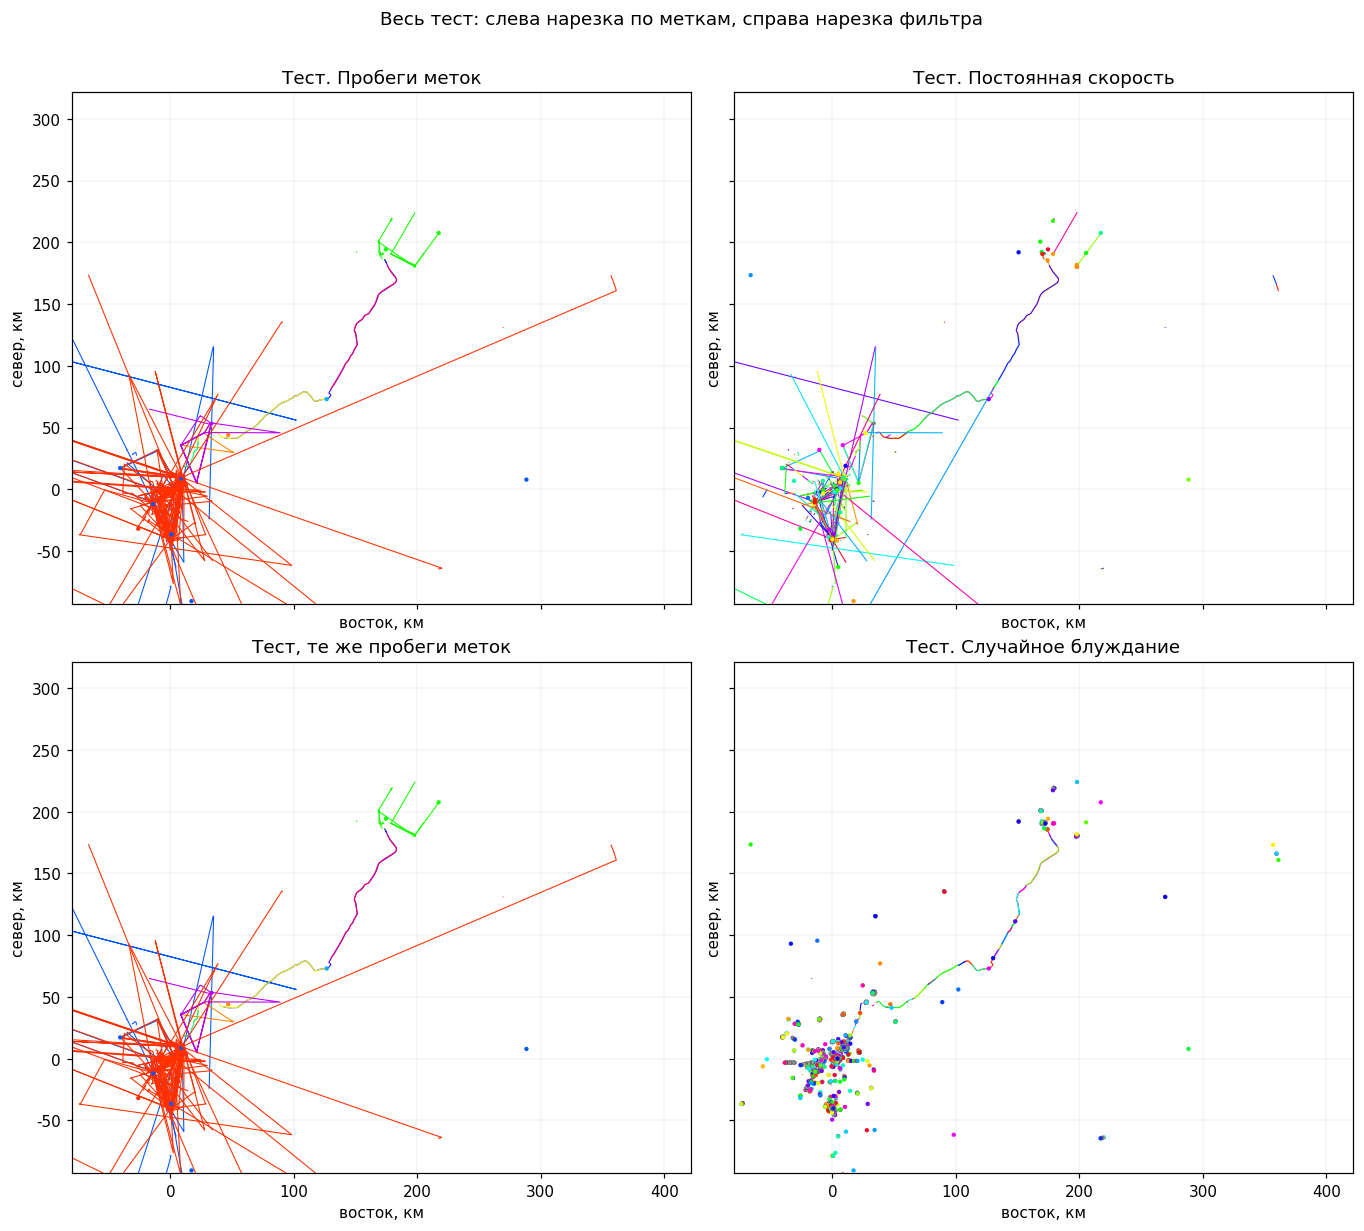

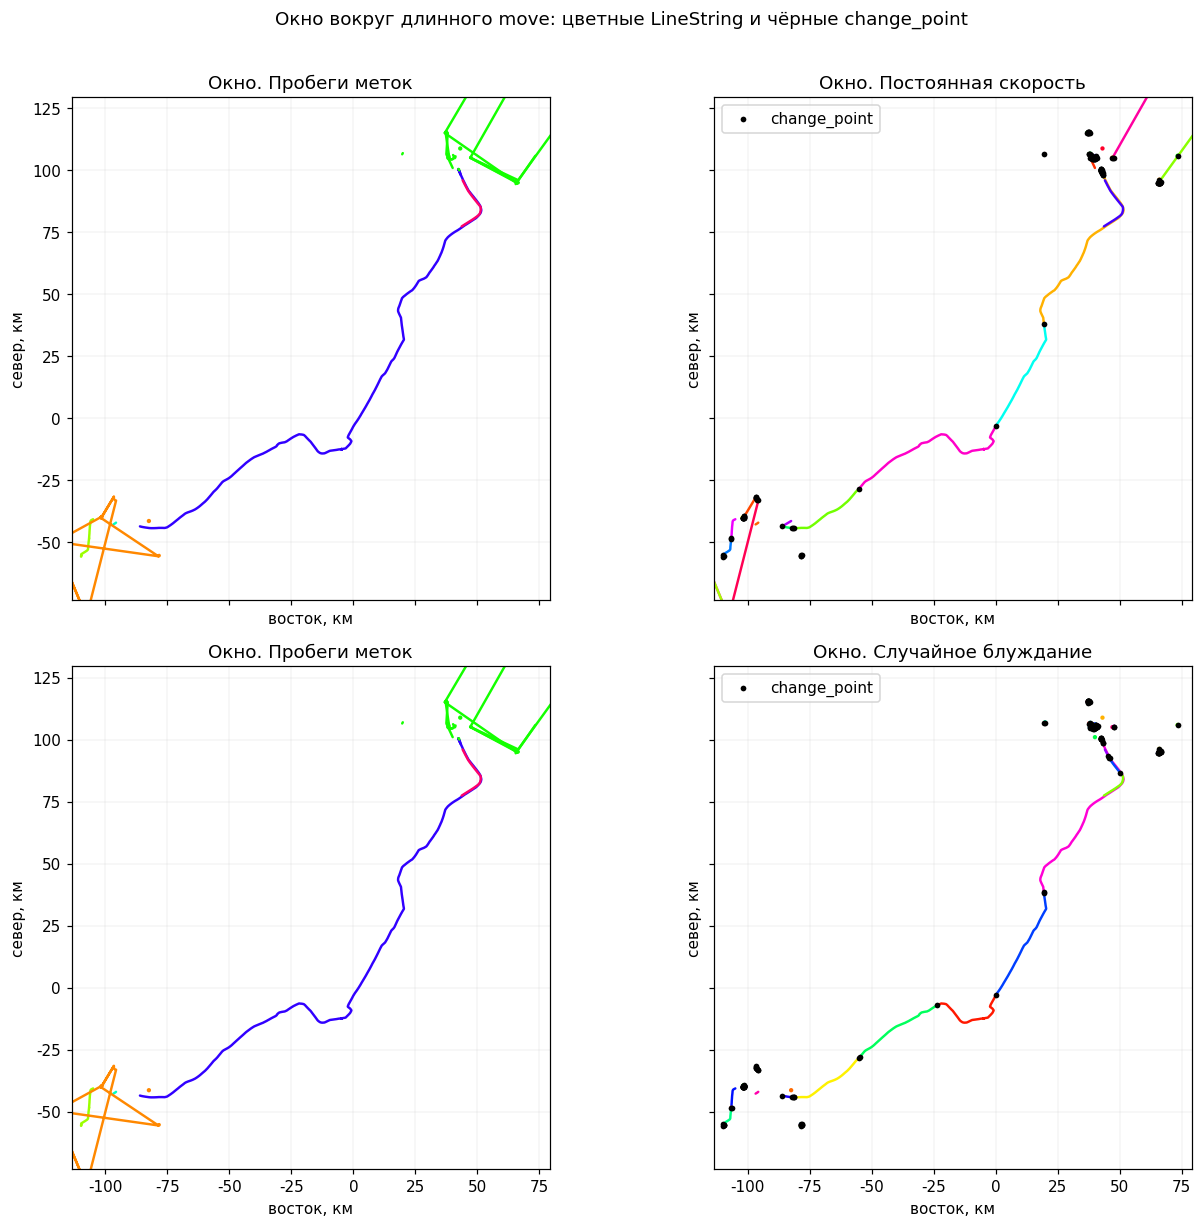

In [6]:
def strokes(x_coord, y_coord, group, time, gap=GAP_SECONDS):
    # Куски ломаной: новый кусок на смене группы и на длинной паузе.
    gid = int(group[0])
    chunk = [[float(x_coord[0]), float(y_coord[0])]]
    start = 0
    produced = []
    for index in range(1, len(group)):
        dt = float(time[index] - time[index - 1])
        if int(group[index]) != gid or dt > gap or dt <= 0.0:
            produced.append((gid, start, index, chunk))
            gid = int(group[index])
            chunk = [[float(x_coord[index]), float(y_coord[index])]]
            start = index
        else:
            chunk.append([float(x_coord[index]), float(y_coord[index])])
    produced.append((gid, start, len(group), chunk))
    return produced


def segment_color(sid):
    hue = (0.61803398875 * (int(sid) + 1)) % 1.0
    return plt.cm.hsv(hue)


def local_km(lat_s, lon_s):
    lat0 = float(np.median(lat_s))
    lon0 = float(np.median(lon_s))
    east = np.radians(lon_s - lon0) * np.cos(np.radians(lat0)) * EARTH_RADIUS_M / 1000.0
    north = np.radians(lat_s - lat0) * EARTH_RADIUS_M / 1000.0
    return east, north


def view_km(lat_s, lon_s, keep=None, bbox=None, pad=0.12):
    # Та же проекция, что у draw_partition: медиана всех точек панели.
    lat0 = float(np.median(lat_s))
    lon0 = float(np.median(lon_s))
    cos0 = np.cos(np.radians(lat0))

    def to_km(lat_v, lon_v):
        east = np.radians(np.asarray(lon_v, dtype=float) - lon0) * cos0 * EARTH_RADIUS_M / 1000.0
        north = np.radians(np.asarray(lat_v, dtype=float) - lat0) * EARTH_RADIUS_M / 1000.0
        return east, north

    if bbox is not None:
        south, west, north, east = bbox
        x0, y0 = to_km(south, west)
        x1, y1 = to_km(north, east)
        return (float(min(x0, x1)), float(max(x0, x1)), float(min(y0, y1)), float(max(y0, y1)))
    chosen = np.ones(len(lat_s), dtype=bool) if keep is None else np.asarray(keep, dtype=bool)
    east, north = to_km(lat_s[chosen], lon_s[chosen])
    x0, x1 = float(np.min(east)), float(np.max(east))
    y0, y1 = float(np.min(north)), float(np.max(north))
    dx = max((x1 - x0) * pad, 0.05)
    dy = max((y1 - y0) * pad, 0.05)
    return (x0 - dx, x1 + dx, y0 - dy, y1 + dy)


def draw_partition(ax, lat_s, lon_s, time, group, title, change=None, linewidth=0.8, view=None):
    east, north = local_km(lat_s, lon_s)
    lines = []
    colors = []
    single_x = []
    single_y = []
    single_c = []
    for gid, start, stop, chunk in strokes(east, north, group, time):
        color = segment_color(gid)
        if len(chunk) >= 2:
            lines.append(chunk)
            colors.append(color)
        else:
            single_x.append(chunk[0][0])
            single_y.append(chunk[0][1])
            single_c.append(color)
    if lines:
        ax.add_collection(LineCollection(lines, colors=colors, linewidths=linewidth, capstyle="round"))
    if single_x:
        ax.scatter(single_x, single_y, c=single_c, s=8, linewidths=0, zorder=3)
    if change is not None and np.any(change):
        ax.scatter(
            east[change],
            north[change],
            s=14,
            c="black",
            marker="o",
            linewidths=0,
            zorder=4,
            label="change_point",
        )
    span_x = max(float(np.max(east) - np.min(east)), 0.05)
    span_y = max(float(np.max(north) - np.min(north)), 0.05)
    if view is None:
        x0 = float(np.min(east)) - 0.04 * span_x
        x1 = float(np.max(east)) + 0.04 * span_x
        y0 = float(np.min(north)) - 0.04 * span_y
        y1 = float(np.max(north)) + 0.04 * span_y
    else:
        x0, x1, y0, y1 = view
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title)
    ax.set_xlabel("восток, км")
    ax.set_ylabel("север, км")
    ax.grid(True, linewidth=0.3, alpha=0.4)


def geographic_lines(lon_s, lat_s, time, group):
    lines = []
    owners = []
    for gid, start, stop, chunk in strokes(lon_s, lat_s, group, time):
        if len(chunk) < 2:
            continue
        lines.append(LineString(chunk))
        owners.append(gid)
    return lines, owners


def segment_frame(kind, split_slice, seg):
    lon_s = lon[split_slice]
    lat_s = lat[split_slice]
    time = t_sec[split_slice]
    mask = anom[split_slice]
    lines, owners = geographic_lines(lon_s, lat_s, time, seg)
    rows = []
    by_owner = {}
    for line, gid in zip(lines, owners):
        by_owner.setdefault(gid, []).append(line)
    for gid in np.unique(seg):
        chosen = seg == gid
        n_points = int(chosen.sum())
        n_anom = int(np.count_nonzero(mask[chosen]))
        majority = "anomaly" if n_anom * 2 >= n_points else "move"
        purity = max(n_anom, n_points - n_anom) / n_points
        parts = by_owner.get(int(gid), [])
        geometry = parts[0] if len(parts) == 1 else None
        if len(parts) > 1:
            # Пауза рвёт линию, но система координат одна. На карте это несколько LineString одного цвета.
            geometry = parts
        rows.append(
            {
                "модель": "постоянная скорость" if kind == "cv" else "случайное блуждание",
                "segment_id": int(gid),
                "n_points": n_points,
                "majority": majority,
                "purity": purity,
                "n_linestrings": len(parts),
                "geometry": geometry,
            }
        )
    return pd.DataFrame(rows)


test_slice = slice(train_end, len(frame))
test_anom = anom[test_slice]
test_run = class_run_id(test_anom)
test_time = t_sec[test_slice]
test_lat = lat[test_slice]
test_lon = lon[test_slice]

segment_tables = {}
line_counts = {}
for kind in ("cv", "rw"):
    seg = runs[(kind, "test", "cut")][5]
    segment_tables[kind] = segment_frame(kind, test_slice, seg)
    n_lines = int(segment_tables[kind]["n_linestrings"].sum())
    n_single = int((segment_tables[kind]["n_points"] == 1).sum())
    line_counts[kind] = (n_lines, n_single)
    title = "Постоянная скорость" if kind == "cv" else "Случайное блуждание"
    print(
        f"{title}: {len(segment_tables[kind])} систем координат, "
        f"{n_lines} LineString, одиночных точек без ребра {n_single}."
    )

preview = pd.concat(
    [
        segment_tables["cv"].drop(columns="geometry").head(6),
        segment_tables["rw"].drop(columns="geometry").head(6),
    ],
    ignore_index=True,
)
display(preview.round(3))

longest = max(
    ((int(np.count_nonzero(test_run == sid)), int(np.flatnonzero(test_run == sid)[0])) for sid in np.unique(test_run) if not test_anom[test_run == sid][0]),
    key=lambda item: item[0],
)
zoom_lo = max(0, longest[1] - 700)
zoom_hi = min(len(test_anom), int(np.flatnonzero(test_run == test_run[longest[1]])[-1]) + 701)
zoom = slice(zoom_lo, zoom_hi)
print(
    f"Окно карты: точки теста [{zoom_lo}, {zoom_hi}), "
    f"внутри самый длинный пробег move, {longest[0]} точек."
)

full_view = view_km(test_lat, test_lon, bbox=MAP_BBOX)
fig, axes = plt.subplots(2, 2, figsize=(12.5, 11), sharex=True, sharey=True)
draw_partition(
    axes[0, 0], test_lat, test_lon, test_time, test_run,
    "Тест. Пробеги меток", linewidth=0.7, view=full_view,
)
draw_partition(
    axes[0, 1], test_lat, test_lon, test_time, runs[("cv", "test", "cut")][5],
    "Тест. Постоянная скорость", linewidth=0.7, view=full_view,
)
draw_partition(
    axes[1, 0], test_lat, test_lon, test_time, test_run,
    "Тест, те же пробеги меток", linewidth=0.7, view=full_view,
)
draw_partition(
    axes[1, 1], test_lat, test_lon, test_time, runs[("rw", "test", "cut")][5],
    "Тест. Случайное блуждание", linewidth=0.7, view=full_view,
)
fig.suptitle("Весь тест: слева нарезка по меткам, справа нарезка фильтра", y=1.01)
fig.tight_layout()
plt.show()

z_lat, z_lon, z_time = test_lat[zoom], test_lon[zoom], test_time[zoom]
zoom_keep = test_run[zoom] == test_run[longest[1]]
zoom_view = view_km(z_lat, z_lon, keep=zoom_keep, pad=0.2)
fig, axes = plt.subplots(2, 2, figsize=(12.5, 11), sharex=True, sharey=True)
draw_partition(axes[0, 0], z_lat, z_lon, z_time, test_run[zoom], "Окно. Пробеги меток", linewidth=1.6, view=zoom_view)
draw_partition(
    axes[0, 1], z_lat, z_lon, z_time, runs[("cv", "test", "cut")][5][zoom],
    "Окно. Постоянная скорость",
    change=runs[("cv", "test", "cut")][3][zoom],
    linewidth=1.6,
    view=zoom_view,
)
draw_partition(axes[1, 0], z_lat, z_lon, z_time, test_run[zoom], "Окно. Пробеги меток", linewidth=1.6, view=zoom_view)
draw_partition(
    axes[1, 1], z_lat, z_lon, z_time, runs[("rw", "test", "cut")][5][zoom],
    "Окно. Случайное блуждание",
    change=runs[("rw", "test", "cut")][3][zoom],
    linewidth=1.6,
    view=zoom_view,
)
axes[0, 1].legend(loc="best", frameon=True)
axes[1, 1].legend(loc="best", frameon=True)
fig.suptitle("Окно вокруг длинного move: цветные LineString и чёрные change_point", y=1.01)
fig.tight_layout()
plt.show()

# Правдоподобие на тесте

Слева — функция распределения сырого фильтра: система меняется только на паузе, поэтому виден провал на точках, которые фильтр ещё не выкинул из текущего режима. Справа — тот же порог на окне длинного `move`, уже с `change_point`. Обе оси `log p` симметрично-логарифмические: полоса хода и глубокие провалы стоят на одном графике. Розовая полоса справа — точки `anomaly`.

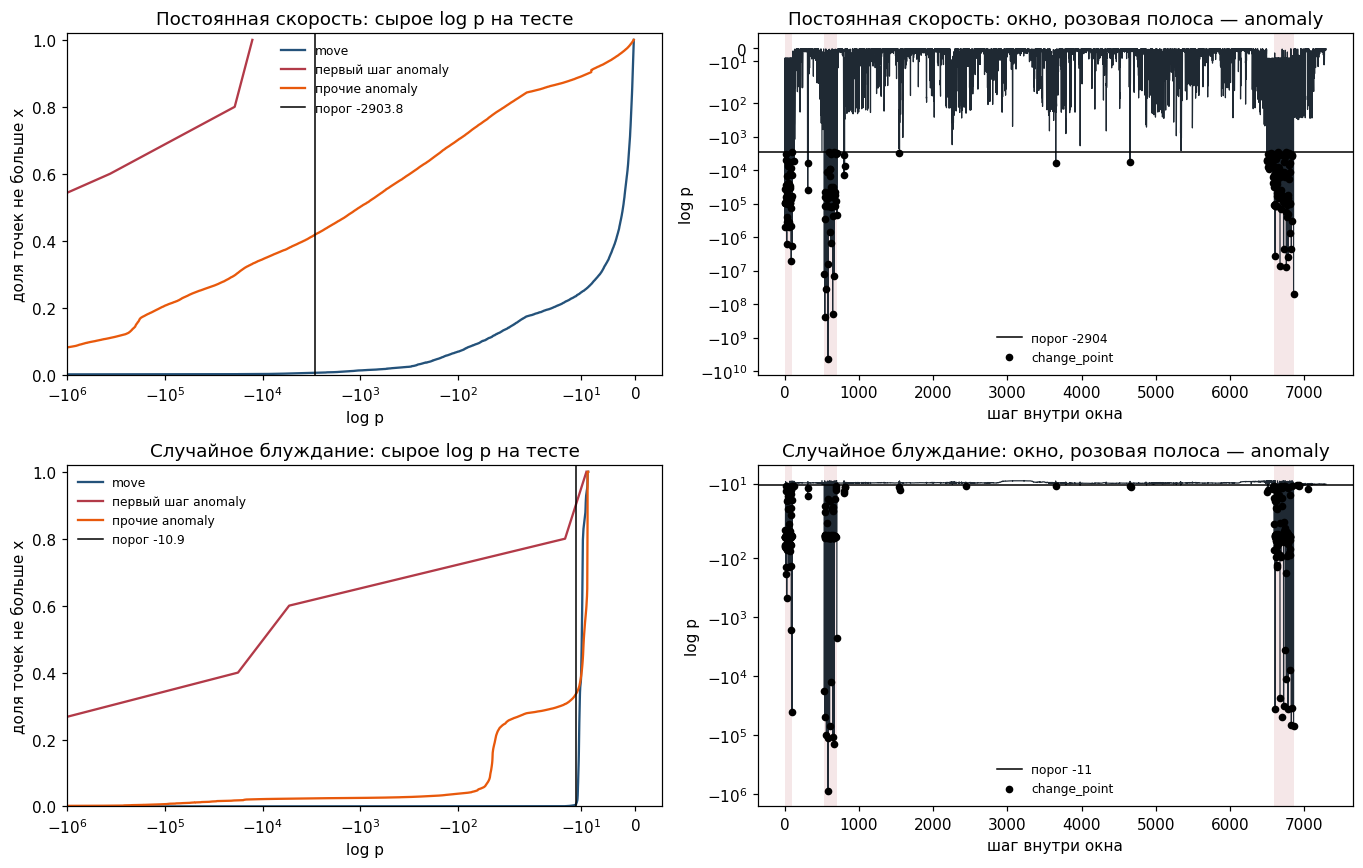

In [7]:
def plot_loglik_hist(ax, groups, tau, title):
    # Функция распределения, ось log p симметрично-логарифмическая:
    # скачок хода около нуля и масса anomaly далеко слева читаются вместе.
    def draw(values, label, color):
        if len(values) == 0:
            return
        ordered = np.sort(np.asarray(values, dtype=float))
        share = np.arange(1, len(ordered) + 1) / len(ordered)
        ax.plot(ordered, share, label=label, color=color, linewidth=1.5)

    draw(groups["move"], "move", "#24527a")
    draw(groups["to_anomaly"], "первый шаг anomaly", "#b23a48")
    draw(groups["anomaly"], "прочие anomaly", "#e8590c")
    ax.axvline(tau, color="black", linewidth=1.0, label=f"порог {tau:.1f}")
    ax.set_xscale("symlog", linthresh=20)
    ax.set_xlim(-1.0e6, 5)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("log p")
    ax.set_ylabel("доля точек не больше x")
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=8)


def plot_loglik_window(ax, loglik, change, mask, tau, title):
    index = np.arange(len(loglik))
    ax.plot(index, loglik, color="#1f2933", linewidth=0.8)
    ax.axhline(tau, color="black", linewidth=1.0, label=f"порог {tau:.0f}")
    if np.any(change):
        ax.scatter(index[change], loglik[change], s=16, c="black", zorder=3, label="change_point")
    spans = strokes(index.astype(float), np.zeros(len(mask)), mask.astype(int), np.arange(len(mask), dtype=float), gap=10**9)
    for gid, start, stop, _chunk in spans:
        if gid == 1:
            ax.axvspan(start, stop, color="#b23a48", alpha=0.12, linewidth=0)
    ax.set_yscale("symlog", linthresh=30)
    ax.set_title(title)
    ax.set_xlabel("шаг внутри окна")
    ax.set_ylabel("log p")
    ax.legend(frameon=False, fontsize=8)


fig, axes = plt.subplots(2, 2, figsize=(12.5, 8))
for row, kind, title, tau in (
    (0, "cv", "Постоянная скорость", tau_cv),
    (1, "rw", "Случайное блуждание", tau_rw),
):
    groups = scout_groups(test_anom, runs[(kind, "test", "scout")][0])
    plot_loglik_hist(axes[row, 0], groups, tau, f"{title}: сырое log p на тесте")
    window_ll = runs[(kind, "test", "cut")][0][zoom]
    window_change = runs[(kind, "test", "cut")][3][zoom]
    plot_loglik_window(
        axes[row, 1],
        window_ll,
        window_change,
        test_anom[zoom],
        tau,
        f"{title}: окно, розовая полоса — anomaly",
    )
fig.tight_layout()
plt.show()

# Что получилось

Цифры ниже относятся к порогу, зафиксированному по `move` обучения, и к тесту. Чистота говорит, смешивает ли отрезок два класса. Медианы длин говорят, совпадает ли нарезка с пробегами меток или только отделяет ход от всего остального.

In [8]:
def paragraph(kind, title, tau, fit_innov, fit_p95, fit_nis):
    item = metrics[(kind, "test")]
    scout = scout_summary[kind]
    print(title)
    print(
        f"На move медиана невязки {fit_innov:.2f} м, p95 {fit_p95:.1f} м, медиана NIS {fit_nis:.2f} "
        f"при медиане χ²(2) = {CHI2_MEDIAN:.2f}. Порог log p = {tau:.2f}, это квантиль {TAIL_PERCENT:g}% хода обучения."
    )
    print(
        f"На тесте, пока фильтр не открывает новую систему после каждого провала, медиана log p у хода {scout['move_med']:.2f}, "
        f"у первого шага move→anomaly {scout['onset_med']:.2f}, у остальных точек anomaly {scout['anom_med']:.2f}. "
        f"Ниже порога оказывается {scout['move_rate']:.1%} шагов хода, {scout['onset_rate']:.0%} первых шагов anomaly "
        f"и {scout['anom_rate']:.0%} прочих точек anomaly."
    )
    print(
        f"С новой системой на каждом провале тест делится на {item['n_seg']} отрезков: "
        f"{item['n_change']} change_point ({item['n_change_anom']} на anomaly, {item['n_change_move']} на move) "
        f"и {item['n_gap']} пауз. Чистота {item['purity']:.3f}, смешанных отрезков {item['mixed']}. "
        f"Из {item['n_bounds']} границ классов правдоподобие ловит {item['hit_ll']}, "
        f"ещё {item['hit_gap']} приходятся только на паузу, пропущено {item['missed']}. "
        f"Точность change_point относительно границ классов {item['precision']:.3f}."
    )
    print(
        f"Медианная длина отрезка с большинством move равна {item['med_len_move']:.0f} "
        f"при медианном пробеге метки {item['true_med_move']:.0f}. "
        f"Самый длинный такой отрезок — {item['longest_move']} точек. "
        f"В отрезках длиннее 200 точек лежит {item['move_in_long']:.0%} точек move. "
        f"Медианная длина отрезка с большинством anomaly равна {item['med_len_anom']:.0f} "
        f"при медианном пробеге метки {item['true_med_anom']:.0f}."
    )
    if item["purity"] >= 0.95 and item["med_len_anom"] <= 0.5 * max(item["true_med_anom"], 1):
        if item["move_in_long"] >= 0.5:
            move_note = (
                f"В отрезках длиннее 200 точек лежит {item['move_in_long']:.0%} точек move: "
                "длинный ход сохраняется большими кусками, а короткая медиана — это обрезки на сбоях и паузах."
            )
        else:
            move_note = (
                f"В отрезках длиннее 200 точек лежит только {item['move_in_long']:.0%} точек move: "
                "ход тоже дробится, не только anomaly."
            )
        print(
            "Отрезок почти не смешивает классы: чистота близка к единице, и границы меток на тесте "
            "попадают либо в change_point, либо в паузу. Это разделение одного класса от другого. "
            "Совпадение с пробегами меток на этом кончается. Медиана отрезка anomaly короткая: внутри класса много шагов "
            "ниже порога, и каждый открывает свой LineString. "
            + move_note
            + " Точность change_point низкая: почти все такие точки лежат внутри anomaly, а не на границе классов."
        )
    elif item["purity"] >= 0.95:
        print(
            "Отрезки почти не смешивают классы, и длины близки к пробегам меток. "
            "На этом тесте нарезка по порогу повторяет нарезку move / anomaly."
        )
    else:
        print(
            "Часть отрезков содержит обе метки. Падение правдоподобия стоит не на каждой смене класса, "
            "и соседние пробеги остаются в одной системе координат."
        )
    if scout["onset_rate"] < 0.5:
        print(
            "Первый шаг anomaly сам по себе ниже порога реже чем в половине переходов. "
            "Часть смен метки — это короткий шаг или пауза, а не кинематический разрыв."
        )
    else:
        print(
            "На входе в anomaly правдоподобие проваливается ниже порога хода: "
            "первая чужая точка открывает change_point, если она не попала в паузу и не служит шагом инициализации скорости."
        )
    print()


paragraph(
    "cv",
    "Постоянная скорость",
    tau_cv,
    float(np.median(move_innov_cv)),
    float(np.percentile(move_innov_cv, 95)),
    float(np.median(move_nis_cv)),
)
paragraph(
    "rw",
    "Случайное блуждание",
    tau_rw,
    float(np.median(move_innov_rw)),
    float(np.percentile(move_innov_rw, 95)),
    float(np.median(move_nis_rw)),
)
print(
    "Случайное блуждание предсказывает «остаться на месте». Штатный шаг около 45 м для него сам является невязкой, "
    "поэтому σ_rw вырастает до размера этого шага, а типичная точка anomaly по правдоподобию близка к ходу. "
    "Постоянная скорость этот шаг вычитает и оставляет невязку около метра: провал на входе в anomaly глубже, "
    "а порог из-за редких сбоев внутри метки move уходит далеко влево. Обе модели ставят change_point на скачках. "
    "У случайного блуждания одиночных точек больше: оно проверяет каждый шаг, а постоянная скорость первый шаг новой системы "
    "тратит на оценку скорости и порогом не режет."
)

Постоянная скорость
На move медиана невязки 0.90 м, p95 7.8 м, медиана NIS 4.03 при медиане χ²(2) = 1.39. Порог log p = -2903.75, это квантиль 0.5% хода обучения.
На тесте, пока фильтр не открывает новую систему после каждого провала, медиана log p у хода -2.20, у первого шага move→anomaly -362955.69, у остальных точек anomaly -1013.58. Ниже порога оказывается 0.5% шагов хода, 100% первых шагов anomaly и 42% прочих точек anomaly.
С новой системой на каждом провале тест делится на 8371 отрезков: 8087 change_point (8050 на anomaly, 37 на move) и 283 пауз. Чистота 1.000, смешанных отрезков 3. Из 12 границ классов правдоподобие ловит 9, ещё 3 приходятся только на паузу, пропущено 0. Точность change_point относительно границ классов 0.001.
Медианная длина отрезка с большинством move равна 7 при медианном пробеге метки 1360. Самый длинный такой отрезок — 2106 точек. В отрезках длиннее 200 точек лежит 93% точек move. Медианная длина отрезка с большинством anomaly равна 2 при медианном пробеге